In [1]:
# 커널은 학습을 통해서 생성된다.

In [4]:
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

(X_train, X_test), (y_train, y_test) = mnist.load_data()

In [5]:
X_train.shape, X_test.shape,y_train.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

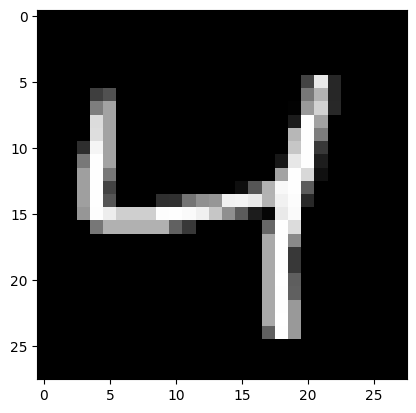

In [11]:
plt.imshow(X_train[2], cmap = 'gray')

In [12]:
import numpy as np

horizontal_filter = np.array([[ 1., 1., 1.],
                              [0., 0., 0.],
                              [-1., -1., -1.]])

vertical_filter = np.array([[1., 0., -1],
                            [1., 0., 1.],
                            [1., 0., -1.]])

In [14]:
test_image = X_train[2]
original_size = test_image.shape[0]
print('original_size = ', original_size)
conv_output_size  = int((original_size - 3) / 1 + 1) # 컨볼루션 연산 진행
print('conv_output_size = ', conv_output_size)

original_size =  28
conv_output_size =  26


In [33]:
filter_size = 3

In [34]:
# 컨볼루션 연산 구현
def get_conv_image(filter):
    filtered_image = np.zeros((conv_output_size, conv_output_size))

    for i in range(conv_output_size):
        for j in range(conv_output_size):
            indice_image = test_image[i : (i + filter_size), j : (j + filter_size)] * filter
            indice_sum = np.sum(indice_image)
    
            if indice_sum > 256:
                indice_sum = 255
                
            filtered_image[i, j] = indice_sum
            
    return filtered_image

In [35]:
vertical_filtered_image = get_conv_image(vertical_filter) # 수직
horizontal_filtered_image = get_conv_image(horizontal_filter) # 수평

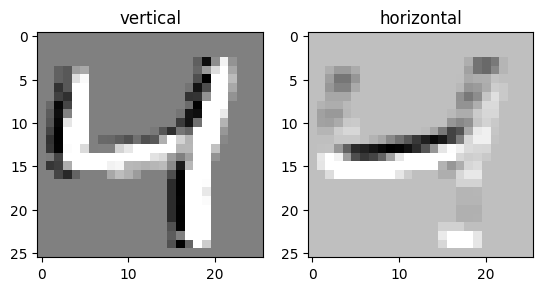

In [36]:
plt.subplot(1, 2, 1)
plt.title('vertical')
plt.imshow(vertical_filtered_image, cmap = 'gray')

plt.subplot(1, 2, 2)
plt.title('horizontal')
plt.imshow(horizontal_filtered_image, cmap = 'gray')

plt.show()

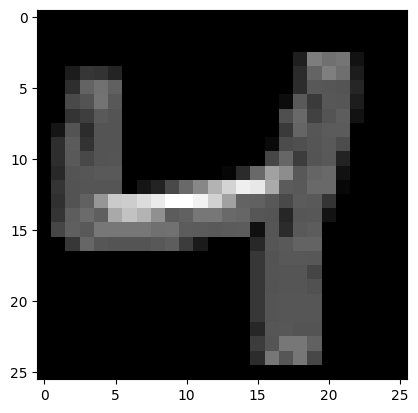

In [37]:
sobel_image = np.sqrt(
    np.square(horizontal_filtered_image)
  + np.square(vertical_filtered_image)
)

plt.imshow(sobel_image, cmap = 'gray')

# sobel_image 기반으로 맥스풀링 구현

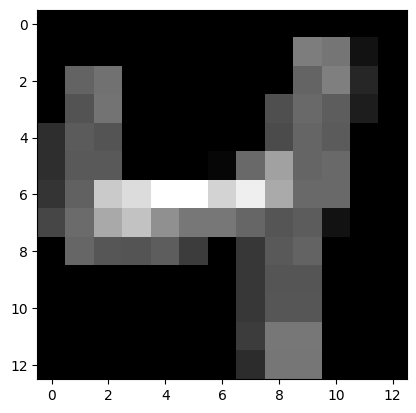

In [38]:
import numpy as np

image = sobel_image
image_x = image.shape[0]
image_y = image.shape[1]

# 스트라이드 지정
new_image_x = int(image_x / 2)
new_image_y = int(image_y / 2)

pooled_image = np.zeros((new_image_x, new_image_y))
for x in range(0, image_x, 2):
    for y in range(0, image_y, 2):
        pooled_image[int(x / 2), int(y / 2)] = np.max(image[x:x + 2, y:y + 2])

plt.imshow(pooled_image, cmap = 'gray')

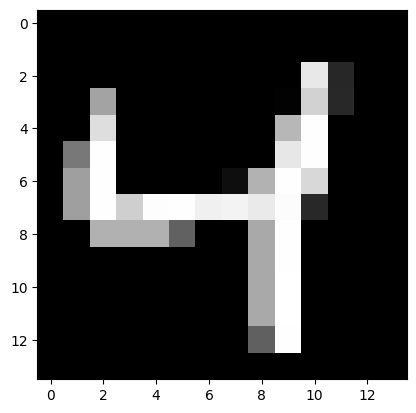

In [39]:
import numpy as np

image = X_train[2]
image_x = image.shape[0]
image_y = image.shape[1]

# 스트라이드 지정
new_image_x = int(image_x / 2)
new_image_y = int(image_y / 2)

pooled_image = np.zeros((new_image_x, new_image_y))
for x in range(0, image_x, 2):
    for y in range(0, image_y, 2):
        pooled_image[int(x / 2), int(y / 2)] = np.max(image[x:x + 2, y:y + 2])

plt.imshow(pooled_image, cmap = 'gray')

In [40]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [65]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [66]:
x_train, x_test = x_train / 255.0, x_test / 255.0

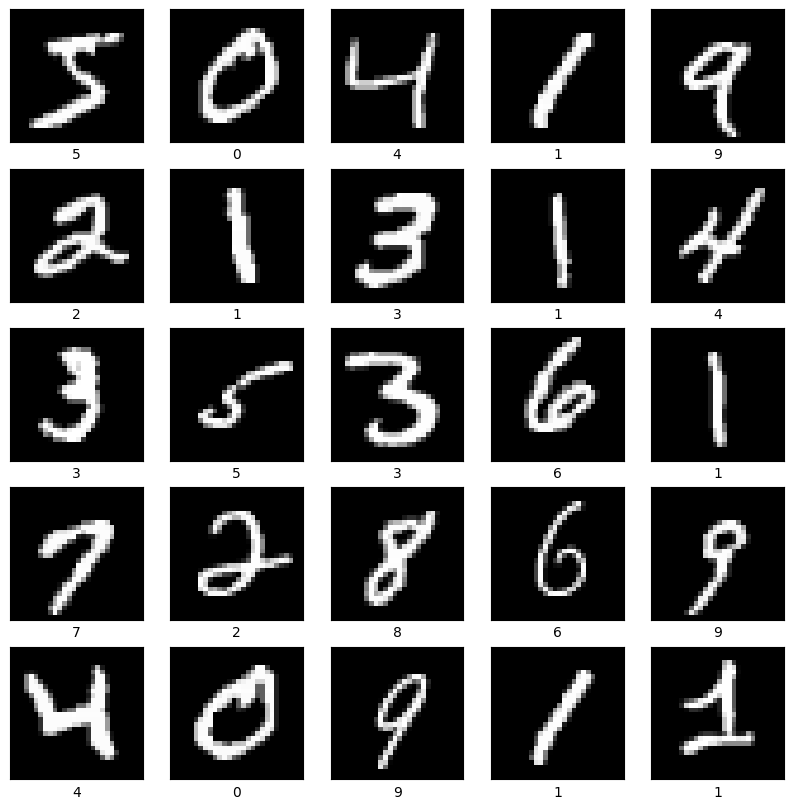

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize = (10, 10))

for index in range(25):
    plt.subplot(5, 5, index + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[index], cmap = 'gray')
    plt.xlabel(str(y_train[index]))
    
plt.show()

* Sequential 방식
* Functional API 방식

#### Conv2D(16, 3 ro (3,3), padding'valid', input_shape=(28, 28, 1) activation = 'rele')
* 첫 번째 인자 : 컨볼루션 필터의 수
* 두 번째 인자 : 컨볼루션 커널의 (행, 열) 크기
* padding : 경계 처리 방법 저으이
    * 'valid' : 유요한 영역만 출력, 출력 이미지 사이즈는 입력 사이즈보다 작아진다.
    * 'same' : 출력 이미지 사이즈가 입력 이미지 사이즈와 동일하다. => 패딩을한다.
* input_shape : 샘플 수를 제외한 입력 형태 정의 모델에서 첫 레이어일 때만 정의한다.
  * (행, 열, 채널 수)로 정의한다. 흑백영상인 경우에는 채널이 1이고, 커널(RGB) 영상인 경우에는 채널을 3으로 설정한다.
* activation : 활성화 함수를 설정한다.
    * relu : 입력뉴런과
    * 'linear' : 입력뉴런과 가중치로 계산된 결과값이 그대로 출력으로 나온다. default = None
    *  'relu' : rectifer 함수, 은닉층에 주로 쓰인다.
    *  'sigmoid' : 시그모이드 함수, 이진 분류 문제에서 출력층에 주로 쓰인다.
    *  'softmax' : 소프트맥스 함수, 다중 분류 문제에서 출력층에 주로 쓰인다.

In [68]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Reshape((28, 28, 1)),
    tf.keras.layers.Conv2D(16, 3, activation = 'relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation = 'relu'),
    tf.keras.layers.Dense(10, activation = 'softmax')
])

In [69]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # 소프트맥스
    metrics=['accuracy']
)

In [70]:
model.fit(x_train, y_train, epochs=5)

Epoch 1/5


1875/1875 [==============================] - 6s 3ms/step - loss: 0.1429 - accuracy: 0.9577
Epoch 2/5
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0459 - accuracy: 0.9856
Epoch 3/5
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0245 - accuracy: 0.9920
Epoch 4/5
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0156 - accuracy: 0.9946
Epoch 5/5
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0090 - accuracy: 0.9969


In [64]:
inputs = keras.Input(shape = (28, 28))
x = layers.Reshape((28, 28, 1))(inputs)
# conv_output_size  = int((original_size - 3) / 1 + 1) # 컨볼루션 연산 진행
x = layers.Conv2D(16, 3, activation = 'relu')(x)
x = layers.Flatten()(x)
x = layers.Dense(128)(x)
x = layers.Dense(10, activation = 'softmax')(x)

outputs = x

model = keras.Model(inputs, outputs)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28)]          0         
                                                                 
 reshape_4 (Reshape)         (None, 28, 28, 1)         0         
                                                                 
 conv2d_3 (Conv2D)           (None, 26, 26, 16)        160       
                                                                 
 flatten_3 (Flatten)         (None, 10816)             0         
                                                                 
 dense_6 (Dense)             (None, 128)               1384576   
                                                                 
 dense_7 (Dense)             (None, 10)                1290      
                                                                 
Total params: 1386026 (5.29 MB)
Trainable params: 1386026 (5.

In [72]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # 소프트맥스
    metrics=['accuracy']
)

In [73]:
model.fit(x_train, y_train, epochs = 5, verbose = 2)

Epoch 1/5
1875/1875 - 6s - loss: 0.0046 - accuracy: 0.9985 - 6s/epoch - 3ms/step
Epoch 2/5
1875/1875 - 6s - loss: 0.0020 - accuracy: 0.9992 - 6s/epoch - 3ms/step
Epoch 3/5
1875/1875 - 6s - loss: 0.0025 - accuracy: 0.9991 - 6s/epoch - 3ms/step
Epoch 4/5
1875/1875 - 6s - loss: 0.0033 - accuracy: 0.9988 - 6s/epoch - 3ms/step
Epoch 5/5
1875/1875 - 6s - loss: 0.0018 - accuracy: 0.9994 - 6s/epoch - 3ms/step


In [74]:
model.evaluate(x_test, y_test)

313/313 [==============================] - 1s 1ms/step - loss: 0.0898 - accuracy: 0.9845


[0.08981873095035553, 0.984499990940094]

In [76]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D

x_train = np.reshape(x_train, (60000, 28, 28, 1))
x_test = np.reshape(x_test, (10000, 28, 28, 1))

In [80]:
model = Sequential()
# 컨볼루션 레이어
model.add(Conv2D(16, kernel_size = (3, 3), activation = 'relu', input_shape = (28, 28, 1)))
model.add(MaxPooling2D(pool_size = (2, 2)))
#--------------------------------------------------------------------------------------------
model.add(Flatten()) # 1차원 구조로 변화하는 작업
model.add(Dense(128, activation = 'relu'))
model.add(Dense(10, activation = 'softmax'))
model.summary()


Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_5 (Conv2D)           (None, 26, 26, 16)        160       
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 16)        0         
 D)                                                              
                                                                 
 flatten_5 (Flatten)         (None, 2704)              0         
                                                                 
 dense_10 (Dense)            (None, 128)               346240    
                                                                 
 dense_11 (Dense)            (None, 10)                1290      
                                                                 
Total params: 347690 (1.33 MB)
Trainable params: 347690 (1.33 MB)
Non-trainable params: 0 (0.00 Byte)
_________________

In [81]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # 소프트맥스
    metrics=['accuracy']
)

In [82]:
model.fit(x_train, y_train, epochs = 5, verbose = 2)

Epoch 1/5
1875/1875 - 10s - loss: 0.1608 - accuracy: 0.9531 - 10s/epoch - 5ms/step
Epoch 2/5
1875/1875 - 8s - loss: 0.0533 - accuracy: 0.9837 - 8s/epoch - 4ms/step
Epoch 3/5
1875/1875 - 7s - loss: 0.0345 - accuracy: 0.9892 - 7s/epoch - 4ms/step
Epoch 4/5
1875/1875 - 7s - loss: 0.0238 - accuracy: 0.9924 - 7s/epoch - 4ms/step
Epoch 5/5
1875/1875 - 8s - loss: 0.0175 - accuracy: 0.9945 - 8s/epoch - 4ms/step


In [83]:
model.evaluate(x_test, y_test)

313/313 [==============================] - 1s 2ms/step - loss: 0.0423 - accuracy: 0.9856


[0.04227125272154808, 0.9855999946594238]

In [87]:
model = Sequential()
# 컨볼루션 레이어
model.add(Conv2D(16, kernel_size = (3, 3), activation = 'relu', input_shape = (28, 28, 1)))
model.add(MaxPooling2D(pool_size = (2, 2)))
model.add(Conv2D(16, kernel_size = (3, 3), activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2, 2)))
#--------------------------------------------------------------------------------------------
model.add(Flatten()) # 1차원 구조로 변화하는 작업
model.add(Dense(128, activation = 'relu'))
model.add(Dense(10, activation = 'softmax'))
model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_8 (Conv2D)           (None, 26, 26, 16)        160       
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 13, 13, 16)        0         
 g2D)                                                            
                                                                 
 conv2d_9 (Conv2D)           (None, 11, 11, 16)        2320      
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 5, 5, 16)          0         
 g2D)                                                            
                                                                 
 flatten_7 (Flatten)         (None, 400)               0         
                                                                 
 dense_14 (Dense)            (None, 128)              

In [88]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # 소프트맥스
    metrics=['accuracy']
)

model.fit(x_train, y_train, epochs = 5, verbose = 2)

model.evaluate(x_test, y_test)

Epoch 1/5
1875/1875 - 8s - loss: 0.1805 - accuracy: 0.9445 - 8s/epoch - 4ms/step
Epoch 2/5
1875/1875 - 8s - loss: 0.0601 - accuracy: 0.9808 - 8s/epoch - 4ms/step
Epoch 3/5
1875/1875 - 8s - loss: 0.0414 - accuracy: 0.9871 - 8s/epoch - 4ms/step
Epoch 4/5
1875/1875 - 8s - loss: 0.0320 - accuracy: 0.9901 - 8s/epoch - 4ms/step
Epoch 5/5
1875/1875 - 8s - loss: 0.0246 - accuracy: 0.9923 - 8s/epoch - 4ms/step
313/313 [==============================] - 1s 2ms/step - loss: 0.0296 - accuracy: 0.9898


[0.029580753296613693, 0.989799976348877]

In [96]:
model = Sequential()
# 컨볼루션 레이어
model.add(Conv2D(8, kernel_size = (3, 3), activation = 'relu', input_shape = (28, 28, 1), padding = 'same'))
model.add(MaxPooling2D(pool_size = (2, 2)))
model.add(Conv2D(16, kernel_size = (3, 3), activation = 'relu', padding = 'same'))
model.add(MaxPooling2D(pool_size = (2, 2)))
model.add(Conv2D(16, kernel_size = (3, 3), activation = 'relu', padding = 'same'))
model.add(MaxPooling2D(pool_size = (2, 2)))
#--------------------------------------------------------------------------------------------
model.add(Flatten()) # 1차원 구조로 변화하는 작업
model.add(Dense(128, activation = 'relu'))
model.add(Dense(10, activation = 'softmax'))
model.summary()

Model: "sequential_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_20 (Conv2D)          (None, 28, 28, 8)         80        
                                                                 
 max_pooling2d_12 (MaxPooli  (None, 14, 14, 8)         0         
 ng2D)                                                           
                                                                 
 conv2d_21 (Conv2D)          (None, 14, 14, 16)        1168      
                                                                 
 max_pooling2d_13 (MaxPooli  (None, 7, 7, 16)          0         
 ng2D)                                                           
                                                                 
 conv2d_22 (Conv2D)          (None, 7, 7, 16)          2320      
                                                                 
 max_pooling2d_14 (MaxPooli  (None, 3, 3, 16)        

In [97]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # 소프트맥스
    metrics=['accuracy']
)

model.fit(x_train, y_train, epochs = 5, verbose = 2)

model.evaluate(x_test, y_test)

Epoch 1/5
1875/1875 - 9s - loss: 0.2099 - accuracy: 0.9353 - 9s/epoch - 5ms/step
Epoch 2/5
1875/1875 - 8s - loss: 0.0673 - accuracy: 0.9790 - 8s/epoch - 4ms/step
Epoch 3/5
1875/1875 - 9s - loss: 0.0512 - accuracy: 0.9839 - 9s/epoch - 5ms/step
Epoch 4/5
1875/1875 - 8s - loss: 0.0410 - accuracy: 0.9868 - 8s/epoch - 4ms/step
Epoch 5/5
1875/1875 - 8s - loss: 0.0350 - accuracy: 0.9890 - 8s/epoch - 5ms/step
313/313 [==============================] - 1s 3ms/step - loss: 0.0381 - accuracy: 0.9874


[0.038051556795835495, 0.9873999953269958]

# 컬러 이미지를 활용한 예제

In [98]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets, layers, models

In [100]:
cifar10 = datasets.cifar10
(train_image, train_labels), (test_image, test_labels) = cifar10.load_data()

170498071/170498071 [==============================] - 218s 1us/step


In [102]:
train_image.shape, train_labels.shape, test_image.shape, test_labels.shape

((50000, 32, 32, 3), (50000, 1), (10000, 32, 32, 3), (10000, 1))

In [105]:
train_labels[:10]

array([[6],
       [9],
       [9],
       [4],
       [1],
       [1],
       [2],
       [7],
       [8],
       [3]], dtype=uint8)

In [129]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
              'dog', 'frog', 'horse', 'ship', 'truck']

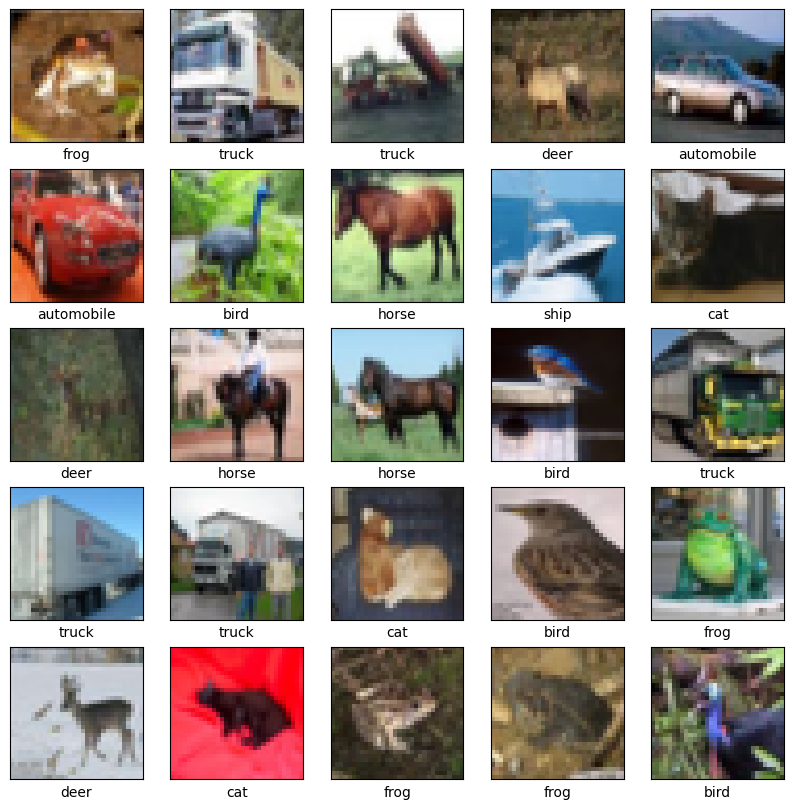

In [110]:
plt.figure(figsize = (10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_image[i])
    plt.xlabel(class_name[train_labels[i][0]]) 

plt.show()

In [111]:
train_images = train_image / 255.0
test_images = test_image / 255.0

In [113]:
model = Sequential()
# 컨볼루션 레이어
model.add(Conv2D(32, kernel_size = (3, 3), activation = 'relu', input_shape = (32, 32, 3)))
model.add(MaxPooling2D(2))
model.add(Conv2D(64, kernel_size = (3, 3), activation = 'relu', padding = 'same'))
model.add(MaxPooling2D(2))
#--------------------------------------------------------------------------------------------
model.add(Flatten()) # 1차원 구조로 변화하는 작업
model.add(Dense(64, activation = 'relu'))
model.add(Dense(10, activation = 'softmax'))
model.summary()

Model: "sequential_14"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_25 (Conv2D)          (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d_17 (MaxPooli  (None, 15, 15, 32)        0         
 ng2D)                                                           
                                                                 
 conv2d_26 (Conv2D)          (None, 15, 15, 64)        18496     
                                                                 
 max_pooling2d_18 (MaxPooli  (None, 7, 7, 64)          0         
 ng2D)                                                           
                                                                 
 flatten_13 (Flatten)        (None, 3136)              0         
                                                                 
 dense_26 (Dense)            (None, 64)              

RGB 계사는 처음에만 함 그 이후에는 하지않음
896 = (3 * 3) * 3 * 32 + 32 = (((3 * 3) * 3) + 1) * 32
      (커널) * RGB * 총채널수 + 바이어스
    
18496 = (3 * 3) * 32 * 64 + 64 = (((3 * 3) * 32) + 1) * 64

In [115]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # 소프트맥스
    metrics=['accuracy']
)

model.fit(train_images, train_labels, epochs = 10, verbose = 2)

Epoch 1/10
1563/1563 - 13s - loss: 1.4040 - accuracy: 0.4972 - 13s/epoch - 8ms/step
Epoch 2/10
1563/1563 - 12s - loss: 1.0454 - accuracy: 0.6353 - 12s/epoch - 7ms/step
Epoch 3/10
1563/1563 - 12s - loss: 0.9038 - accuracy: 0.6854 - 12s/epoch - 8ms/step
Epoch 4/10
1563/1563 - 12s - loss: 0.8186 - accuracy: 0.7145 - 12s/epoch - 8ms/step
Epoch 5/10
1563/1563 - 12s - loss: 0.7479 - accuracy: 0.7381 - 12s/epoch - 8ms/step
Epoch 6/10
1563/1563 - 12s - loss: 0.6891 - accuracy: 0.7600 - 12s/epoch - 8ms/step
Epoch 7/10
1563/1563 - 13s - loss: 0.6370 - accuracy: 0.7755 - 13s/epoch - 8ms/step
Epoch 8/10
1563/1563 - 13s - loss: 0.5901 - accuracy: 0.7940 - 13s/epoch - 8ms/step
Epoch 9/10
1563/1563 - 13s - loss: 0.5472 - accuracy: 0.8083 - 13s/epoch - 8ms/step
Epoch 10/10
1563/1563 - 12s - loss: 0.5023 - accuracy: 0.8226 - 12s/epoch - 8ms/step


In [116]:
test_loss, test_acc = model.evaluate(test_images, test_labels)

print('Test loss : ', test_loss)
print('Test accuracy : ', test_acc)

313/313 [==============================] - 1s 4ms/step - loss: 0.9327 - accuracy: 0.7062
Test loss :  0.9327329993247986
Test accuracy :  0.7062000036239624


In [143]:
predictions = model.predict(test_images)

313/313 [==============================] - 1s 4ms/step


In [144]:
def plot_image(i, predictions_array, true_labels, images):
    predictions_array = predictions_array[i]
    true_label = true_labels[i][0]  # 또는 .item()
    img = images[i]

    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img, cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    color = 'blue' if predicted_label == true_label else 'red'

    plt.xlabel("{} {:2.0f}% ({})".format(
        class_names[predicted_label],
        100 * np.max(predictions_array),
        class_names[true_label]),
        color=color)

def plot_value_array(i, predictions_array, true_labels):
    predictions_array = predictions_array[i]
    true_label = true_labels[i][0]  # 또는 .item()

    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])

    bars = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])

    predicted_label = np.argmax(predictions_array)
    bars[predicted_label].set_color('red')
    bars[true_label].set_color('blue')


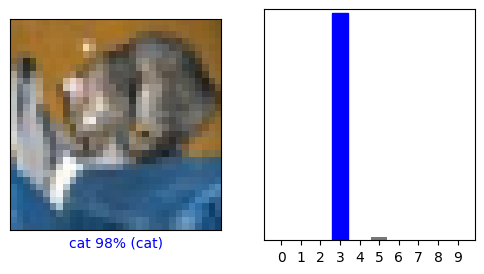

In [145]:
i = 0
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plot_image(i, predictions, test_labels, test_images)
plt.subplot(1, 2, 2)
plot_value_array(i, predictions, test_labels)
plt.show()